In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df_auto = pd.read_csv('auto-mpg.csv')
df_auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [4]:
df_auto.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
# Converting 'horsepower' to numeric, coercing errors to NaN
df_auto['horsepower'] = pd.to_numeric(df_auto['horsepower'], errors='coerce')

In [6]:
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [7]:
# defining features and target variable
X = df_auto[['displacement']]
y = df_auto['mpg']

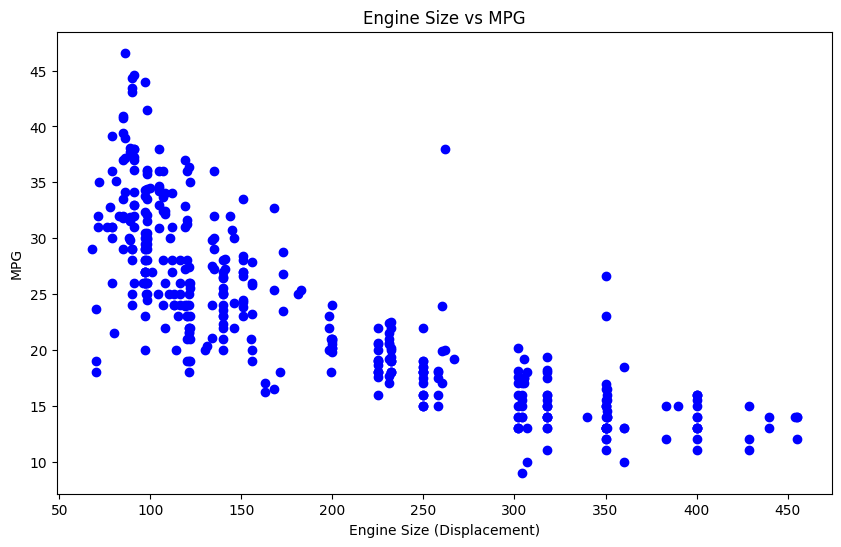

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue')
plt.title('Engine Size vs MPG')
plt.xlabel('Engine Size (Displacement)')
plt.ylabel('MPG')
plt.show()

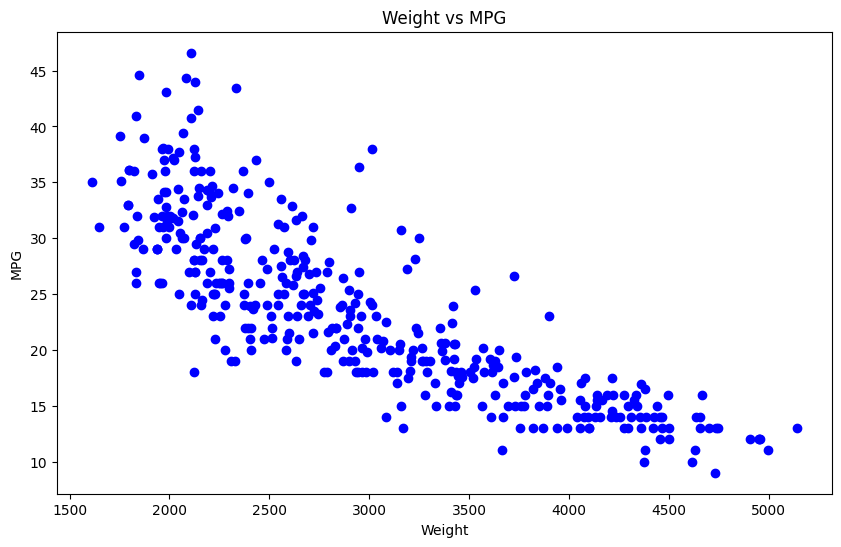

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df_auto[['weight']], df_auto['mpg'], color='blue')
plt.title('Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

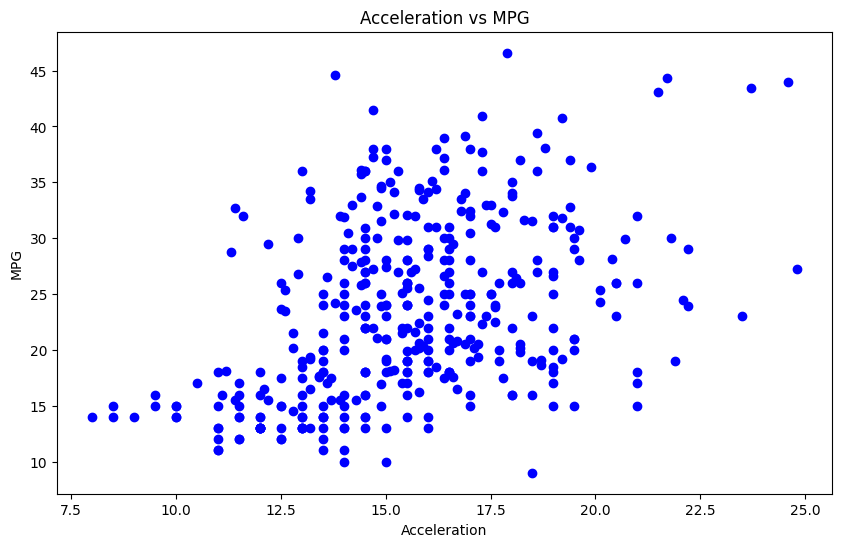

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df_auto[['acceleration']], df_auto['mpg'], color='blue')
plt.title('Acceleration vs MPG')
plt.xlabel('Acceleration')
plt.ylabel('MPG')
plt.show()

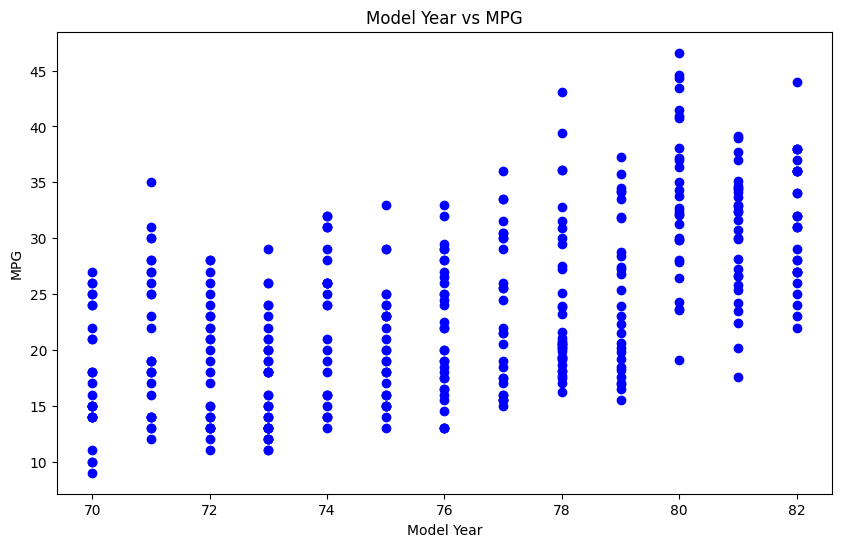

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df_auto[['model year']], df_auto['mpg'], color='blue')
plt.title('Model Year vs MPG')
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.show()

In [15]:
# What is correlation? - strength and direction of a linear relationship between two variables
# Correlation coefficient (r) ranges from -1 to 1
correlation_matrix = df_auto['displacement'].corr(df_auto['mpg'])
print(f"Correlation between displacement and mpg: {correlation_matrix:.2f}")

Correlation between displacement and mpg: -0.80


In [17]:
features = ['weight', 'acceleration', 'model year', 'horsepower']

for feature in features:
    correlation = df_auto[feature].corr(df_auto['mpg'])
    print(f"Correlation between {feature} and mpg: {correlation:.2f}")

Correlation between weight and mpg: -0.83
Correlation between acceleration and mpg: 0.42
Correlation between model year and mpg: 0.58
Correlation between horsepower and mpg: -0.78


### Causation

Engine size and MPG are negatively correlated

In [19]:
X = df_auto[['displacement']]
y = df_auto['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression() #creates the model object
model.fit(X_train, y_train) #fits the model to the training data, learning the relationship between displacement and mpg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
intercept = model.intercept_
slope = model.coef_[0]
print(f"Intercept: {intercept:.2f}")
print(f"Slope: {slope:.2f}")

Intercept: 35.45
Slope: -0.06


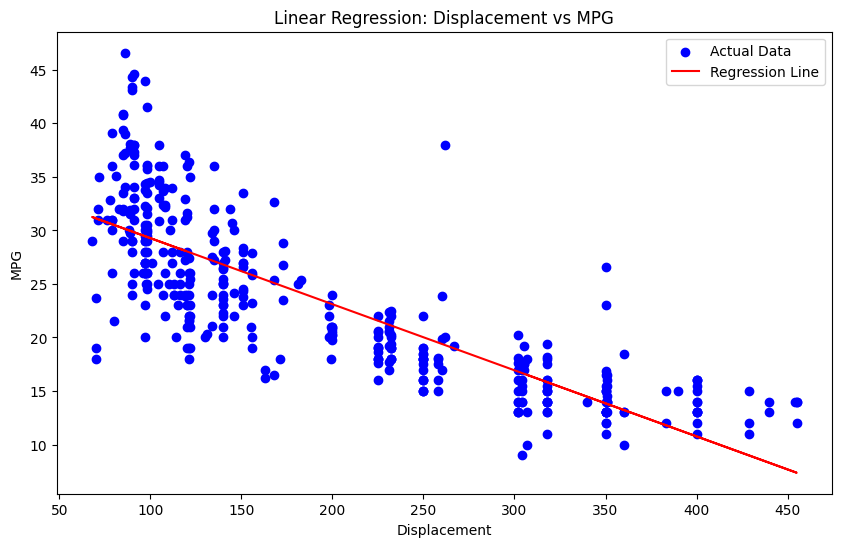

In [22]:
y_line = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_line, color='red', label='Regression Line')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Linear Regression: Displacement vs MPG')
plt.legend()
plt.show()